# Alternative Models — Gesture Classification

**Project:** `manos-hablando` (LSM → Spanish text)  
**Stage:** Week 5, Activity 4 — Alternative models

---

## Objective

Build multiple **individual** (non-ensemble) classifiers for the 29-letter LSM hand-sign classification problem and compare them. Different algorithms exploit different aspects of the feature space; building several lets us pick the one that fits this problem best. Then we tune the top performers and select a final model.

Steps:

1. Build at least **6 different individual models** with varied algorithms.
2. Compare their performance on a held-out validation set.
3. Select the **two best** models.
4. Tune those two with randomized hyperparameter search.
5. Choose the **final individual model**.

Primary metric: **F1-Macro** (treats every letter equally regardless of frequency).

## 1. Environment and Imports

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from manos_hablando.dataset_full import load_full_keypoints
from manos_hablando.dataset_video import normalize_video_sequences

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")

2026-06-02 22:53:13.222 | INFO     | manos_hablando.config:<module>:11 - PROJ_ROOT path is: /Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando


## 2. Data Loading and Aggregation

We load the unified 29-class keypoint dataset from the project's full pipeline (`data/processed/full_keypoints.json`). Each entry is a sequence of `(num_frames, 21, 3)` MediaPipe landmarks — single-frame for static letters (replicated to 30 frames at load time) and multi-frame for dynamic letters (J, K, Ñ, Q, X, Z).

Classical ML models expect a **fixed-length feature vector** per sample, so we:

1. Apply per-frame wrist-centered normalization (the same scheme used by every other pipeline in this project).
2. Aggregate each variable-length sequence to its temporal **mean** → `(63,)` features per sample.

Mean pooling is the identity transform for static letters (their 30 frames are identical replicas) and the average pose for dynamic letters — a sensible single-shape summary.

In [2]:
sequences, y_all, encoder = load_full_keypoints()
sequences = normalize_video_sequences(sequences)

# Mean-pool over time → (63,) per sample
X_all = np.stack([seq.mean(axis=0) for seq in sequences]).astype(np.float32)
class_names = list(encoder.classes_)

print(f"X_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
print(f"Classes ({len(class_names)}): {class_names}")

2026-06-02 22:53:18.274 | INFO     | manos_hablando.dataset_full:load_full_keypoints:50 - Loaded 31839 entries from /Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando/data/processed/full_keypoints.json


Loading full keypoints: 100%|██████████| 31839/31839 [00:00<00:00, 98701.07it/s] 


2026-06-02 22:53:18.621 | INFO     | manos_hablando.dataset_full:load_full_keypoints:77 - Classes (29): [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.str_('L'), np.str_('LL'), np.str_('M'), np.str_('N'), np.str_('O'), np.str_('P'), np.str_('Q'), np.str_('R'), np.str_('RR'), np.str_('S'), np.str_('T'), np.str_('U'), np.str_('V'), np.str_('W'), np.str_('X'), np.str_('Y'), np.str_('Z'), np.str_('Ñ')]
2026-06-02 22:53:18.621 | INFO     | manos_hablando.dataset_full:load_full_keypoints:78 - Static (replicated): 31217 | Dynamic: 622
2026-06-02 22:53:18.623 | INFO     | manos_hablando.dataset_full:load_full_keypoints:79 - Sequence lengths: min=27, max=176, mean=31.0
X_all shape: (31839, 63)
y_all shape: (31839,)
Classes (29): [np.str_('A'), np.str_('B'), np.str_('C'), np.str_('D'), np.str_('E'), np.str_('F'), np.str_('G'), np.str_('H'), np.str_('I'), np.str_('J'), np.str_('K'), np.s

### 2.1 Balanced subsample

The MSL-ABC data contributes ~1.5k samples per static letter, while dynamic letters (J, K, Ñ, Q, X, Z) only have ~100 videos each. A raw fit would be class-imbalanced and unnecessarily slow (SVM is O(n²)). We cap each class to `MAX_PER_CLASS` random samples so the comparison is fair across letters and fits run in seconds, not minutes.

Bump `MAX_PER_CLASS` higher if you want to use more of the dataset — at 500 the total is ~10k, train fits ~6k samples, which keeps SVM and tuning comfortable.

In [3]:
MAX_PER_CLASS = 500

rng = np.random.default_rng(RANDOM_STATE)
kept_indices: list[int] = []
for cls in np.unique(y_all):
    cls_idx = np.where(y_all == cls)[0]
    if len(cls_idx) > MAX_PER_CLASS:
        cls_idx = rng.choice(cls_idx, size=MAX_PER_CLASS, replace=False)
    kept_indices.extend(cls_idx.tolist())

kept_indices = np.array(sorted(kept_indices))
X = X_all[kept_indices]
y = y_all[kept_indices]

print(f"After balancing: X={X.shape}, y={y.shape}")
print(f"Per-class counts (min/median/max): "
      f"{int(np.bincount(y).min())} / "
      f"{int(np.median(np.bincount(y)))} / "
      f"{int(np.bincount(y).max())}")

After balancing: X=(11311, 63), y=(11311,)
Per-class counts (min/median/max): 89 / 500 / 500


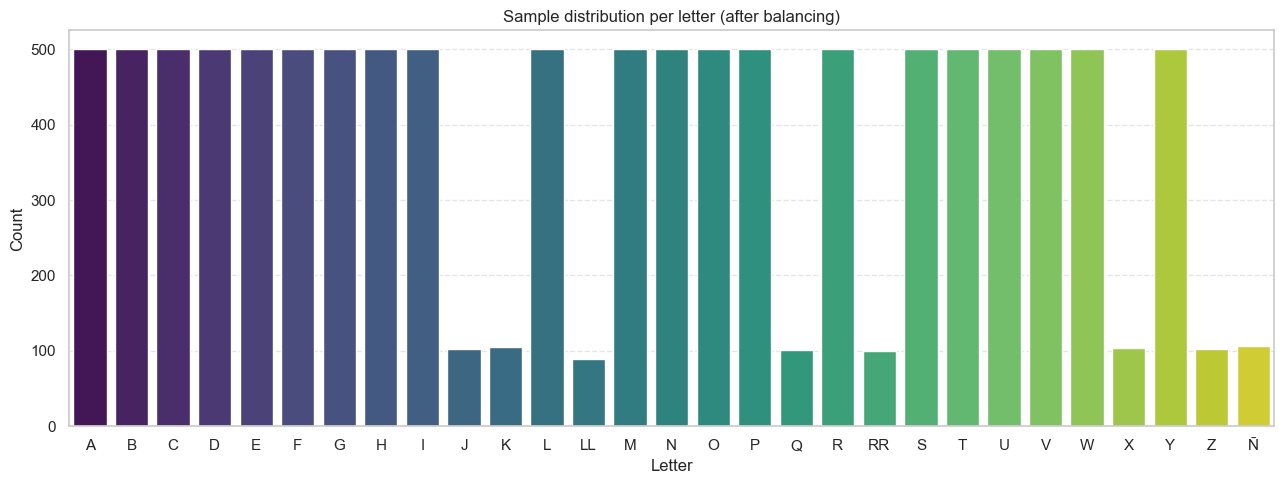

In [4]:
labels_str = encoder.inverse_transform(y)
letter_order = sorted(set(labels_str))

plt.figure(figsize=(13, 5))
sns.countplot(x=labels_str, hue=labels_str, order=letter_order, palette="viridis", legend=False)
plt.title("Sample distribution per letter (after balancing)")
plt.xlabel("Letter")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Train / Validation / Test Split

Three-way stratified split:

- **Train (60%)** — fits each algorithm.
- **Validation (20%)** — model comparison and hyperparameter tuning.
- **Test (20%)** — held out for the final unbiased estimate.

Stratification preserves per-class proportions in every subset, so rare classes (e.g. LL, RR after the cap) stay represented everywhere.

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Classes: {len(class_names)}")

Train: (6786, 63) | Val: (2262, 63) | Test: (2263, 63)
Classes: 29


### 3.1 Feature scaling

Wrist-relative normalization already pulls features into a comparable range, but algorithms sensitive to feature scale (SVM, KNN, MLP, LogisticRegression) still benefit from `StandardScaler`. We apply it as a step inside each model's `Pipeline` so the train/val/test split stays leak-free.

In [6]:
# Sanity check: confirm scaling produces ~zero mean and unit variance.
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
print("First 5 feature means after scaling :", X_train_scaled.mean(axis=0)[:5].round(4))
print("First 5 feature stds  after scaling :", X_train_scaled.std(axis=0)[:5].round(4))

First 5 feature means after scaling : [ 0.  0.  0. -0. -0.]
First 5 feature stds  after scaling : [0. 0. 0. 1. 1.]


## 4. Building and Evaluating Individual Models

Seven varied algorithms (linear, tree-based, instance-based, kernel-based, probabilistic, neural):

| Algorithm | Family | Why it's interesting here |
|-----------|--------|---------------------------|
| **LogisticRegression** | Linear | Simple, fast baseline for whether the classes are linearly separable in the 63-D wrist-relative space. |
| **DecisionTree** | Tree | Captures axis-aligned splits; tells us if any single landmark dimension is discriminative. |
| **RandomForest** | Bagging of trees | Robust, low-variance variant of decision trees; tends to dominate on tabular features. |
| **SVM (RBF)** | Kernel | Excellent for geometric features in moderate dimensions; the wrist-centered coordinates are exactly that. |
| **KNN** | Instance-based | Direct test of whether the same hand pose lands close in feature space. |
| **MLP** | Neural | Learns non-linear combinations across the 63 coordinates; the deep-learning analog inside sklearn. |
| **GaussianNB** | Probabilistic | Strong assumption of feature independence — useful as a lower-bound reference. |

For each model we measure: training time, accuracy, F1-Macro, precision (macro), recall (macro). **F1-Macro** is the primary metric.

In [7]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "SVM":                SVC(random_state=RANDOM_STATE),
    "KNN":                KNeighborsClassifier(),
    "MLP":                MLPClassifier(max_iter=500, random_state=RANDOM_STATE),
    "GaussianNB":         GaussianNB(),
}

results = []
trained = {}

for name, estimator in models.items():
    print(f"Training {name}…")
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", estimator),
    ])

    start = time.time()
    pipe.fit(X_train, y_train)
    elapsed = time.time() - start

    preds = pipe.predict(X_val)
    results.append({
        "model":           name,
        "train_time (s)":  round(elapsed, 3),
        "accuracy":        round(float(accuracy_score(y_val, preds)), 4),
        "f1_macro":        round(float(f1_score(y_val, preds, average="macro")), 4),
        "precision_macro": round(float(precision_score(y_val, preds, average="macro", zero_division=0)), 4),
        "recall_macro":    round(float(recall_score(y_val, preds, average="macro")), 4),
    })
    trained[name] = pipe

results_df = (
    pd.DataFrame(results)
      .sort_values("f1_macro", ascending=False)
      .reset_index(drop=True)
)
display(results_df)

Training LogisticRegression…
Training DecisionTree…
Training RandomForest…
Training SVM…
Training KNN…
Training MLP…
Training GaussianNB…


,model,train_time (s),accuracy,f1_macro,precision_macro,recall_macro
0,MLP,3.377,0.9443,0.9425,0.9399,0.9471
1,RandomForest,0.386,0.8970,0.8971,0.9012,0.8959
2,LogisticRegression,0.286,0.9019,0.8781,0.8801,0.8808
3,SVM,0.322,0.8886,0.8768,0.8898,0.8733
4,KNN,0.003,0.8338,0.8407,0.8428,0.8418
5,DecisionTree,0.332,0.7913,0.7802,0.7796,0.7838
6,GaussianNB,0.008,0.6618,0.6447,0.6538,0.6778


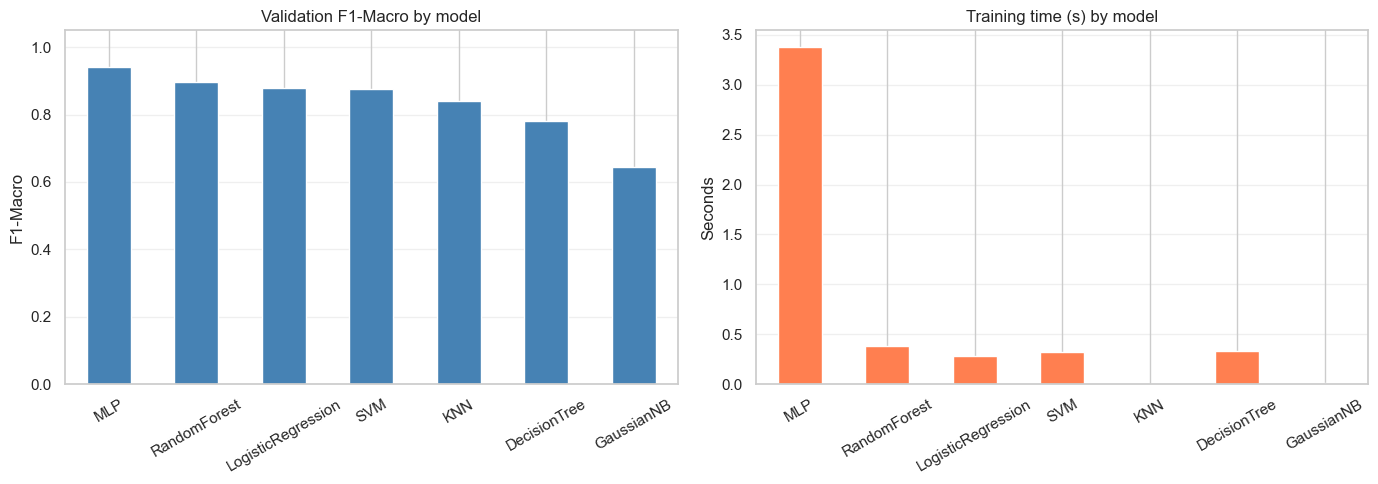

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.plot(
    x="model", y="f1_macro",
    kind="bar", ax=axes[0], legend=False, color="steelblue",
)
axes[0].set_title("Validation F1-Macro by model")
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel("F1-Macro")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(axis="y", alpha=0.3)

results_df.plot(
    x="model", y="train_time (s)",
    kind="bar", ax=axes[1], legend=False, color="coral",
)
axes[1].set_title("Training time (s) by model")
axes[1].set_ylabel("Seconds")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 4.1 Picking the top 2

We rank by validation F1-Macro and pull the two best for hyperparameter tuning.

In [9]:
top_two = results_df.head(2)["model"].tolist()
print("Top 2 models by validation F1-Macro:", top_two)

Top 2 models by validation F1-Macro: ['MLP', 'RandomForest']


## 5. Tuning the Best Models

Both top performers get the same treatment: a `RandomizedSearchCV` over a small but meaningful parameter grid, optimizing `f1_macro` with 3-fold cross-validation on the **training set only**. Validation set remains untouched for fair comparison; test set untouched until the final pick.

### 5.1 Tune MLP

In [10]:
mlp_param_dist = {
    "clf__hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50), (128, 64)],
    "clf__alpha":              [1e-4, 1e-3, 1e-2, 1e-1],
    "clf__learning_rate_init": [1e-4, 1e-3, 1e-2],
    "clf__activation":         ["relu", "tanh"],
}

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(max_iter=500, random_state=RANDOM_STATE)),
])

mlp_search = RandomizedSearchCV(
    mlp_pipe,
    param_distributions=mlp_param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
mlp_search.fit(X_train, y_train)

print("Best MLP params:", mlp_search.best_params_)

mlp_val_preds = mlp_search.predict(X_val)
mlp_tuned = {
    "accuracy":        round(float(accuracy_score(y_val, mlp_val_preds)), 4),
    "f1_macro":        round(float(f1_score(y_val, mlp_val_preds, average="macro")), 4),
    "precision_macro": round(float(precision_score(y_val, mlp_val_preds, average="macro", zero_division=0)), 4),
    "recall_macro":    round(float(recall_score(y_val, mlp_val_preds, average="macro")), 4),
}
print("MLP tuned metrics:", mlp_tuned)
display(pd.DataFrame([mlp_tuned], index=["MLP (tuned)"]))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/cbarrien/Documents/Projects/Personal/LSM/manos-hablando/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_percep

Best MLP params: {'clf__learning_rate_init': 0.001, 'clf__hidden_layer_sizes': (128, 64), 'clf__alpha': 0.001, 'clf__activation': 'tanh'}
MLP tuned metrics: {'accuracy': 0.9403, 'f1_macro': 0.9415, 'precision_macro': 0.9358, 'recall_macro': 0.9492}


,accuracy,f1_macro,precision_macro,recall_macro
MLP (tuned),0.9403,0.9415,0.9358,0.9492


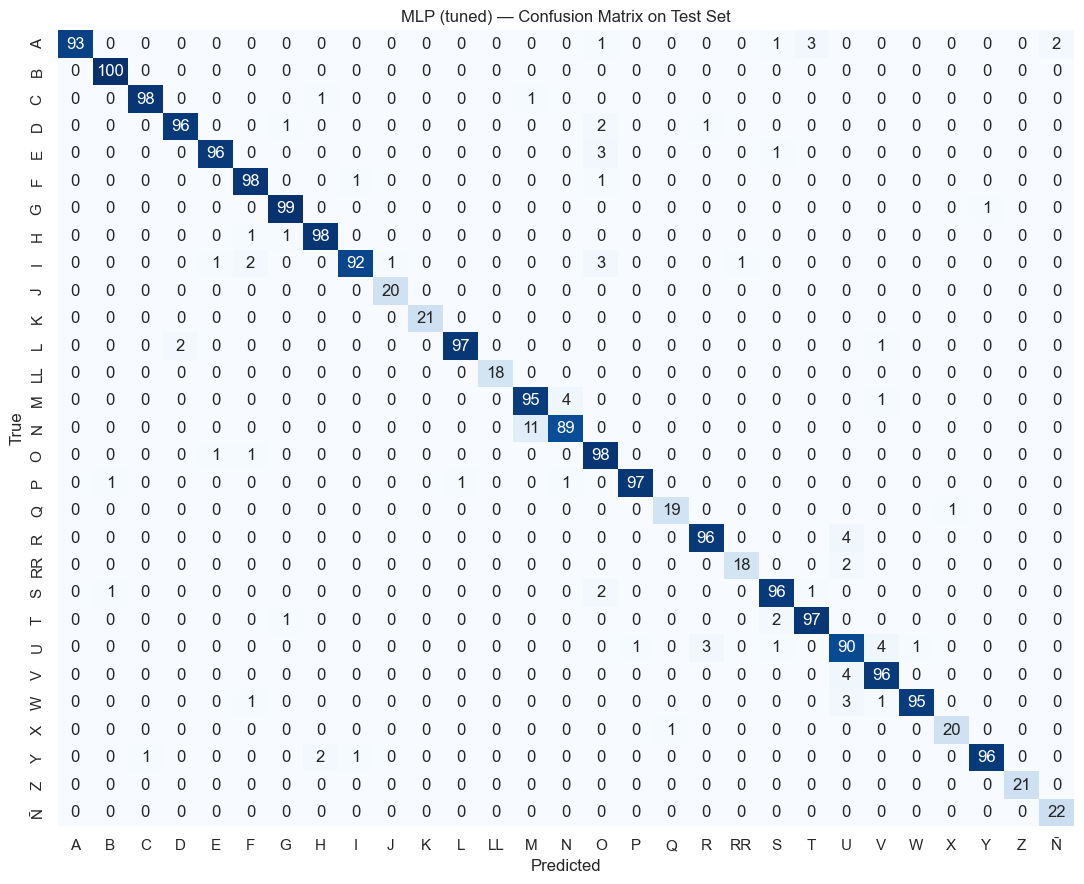


Classification report on test set:

              precision    recall  f1-score   support

           A     1.0000    0.9300    0.9637       100
           B     0.9804    1.0000    0.9901       100
           C     0.9899    0.9800    0.9849       100
           D     0.9796    0.9600    0.9697       100
           E     0.9796    0.9600    0.9697       100
           F     0.9515    0.9800    0.9655       100
           G     0.9706    0.9900    0.9802       100
           H     0.9703    0.9800    0.9751       100
           I     0.9787    0.9200    0.9485       100
           J     0.9524    1.0000    0.9756        20
           K     1.0000    1.0000    1.0000        21
           L     0.9898    0.9700    0.9798       100
          LL     1.0000    1.0000    1.0000        18
           M     0.8879    0.9500    0.9179       100
           N     0.9468    0.8900    0.9175       100
           O     0.8909    0.9800    0.9333       100
           P     0.9898    0.9700    0.9798 

In [11]:
mlp_test_preds = mlp_search.predict(X_test)
cm = confusion_matrix(y_test, mlp_test_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Blues", cbar=False,
)
plt.title("MLP (tuned) — Confusion Matrix on Test Set")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\nClassification report on test set:\n")
print(classification_report(y_test, mlp_test_preds, target_names=class_names, digits=4))

### 5.2 Tune RandomForest

In [12]:
rf_param_dist = {
    "clf__n_estimators":      [100, 200, 500, 1000],
    "clf__max_depth":         [None, 10, 20, 30, 50],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf":  [1, 2, 4],
}

rf_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train)

print("Best RF params:", rf_search.best_params_)

rf_val_preds = rf_search.predict(X_val)
rf_tuned = {
    "accuracy":        round(float(accuracy_score(y_val, rf_val_preds)), 4),
    "f1_macro":        round(float(f1_score(y_val, rf_val_preds, average="macro")), 4),
    "precision_macro": round(float(precision_score(y_val, rf_val_preds, average="macro", zero_division=0)), 4),
    "recall_macro":    round(float(recall_score(y_val, rf_val_preds, average="macro")), 4),
}
print("RandomForest tuned metrics:", rf_tuned)
display(pd.DataFrame([rf_tuned], index=["RandomForest (tuned)"]))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_depth': 50}
RandomForest tuned metrics: {'accuracy': 0.9027, 'f1_macro': 0.9032, 'precision_macro': 0.9073, 'recall_macro': 0.902}


,accuracy,f1_macro,precision_macro,recall_macro
RandomForest (tuned),0.9027,0.9032,0.9073,0.902


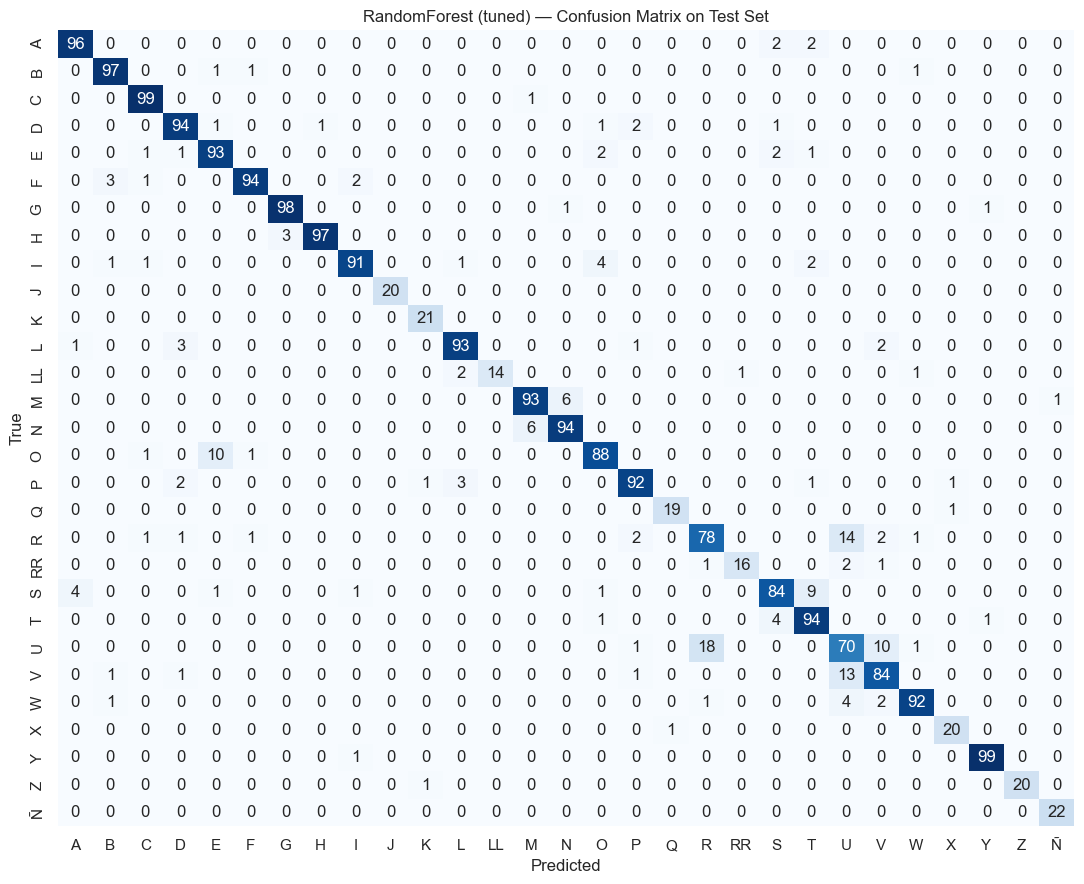


Classification report on test set:

              precision    recall  f1-score   support

           A     0.9505    0.9600    0.9552       100
           B     0.9417    0.9700    0.9557       100
           C     0.9519    0.9900    0.9706       100
           D     0.9216    0.9400    0.9307       100
           E     0.8774    0.9300    0.9029       100
           F     0.9691    0.9400    0.9543       100
           G     0.9703    0.9800    0.9751       100
           H     0.9898    0.9700    0.9798       100
           I     0.9579    0.9100    0.9333       100
           J     1.0000    1.0000    1.0000        20
           K     0.9130    1.0000    0.9545        21
           L     0.9394    0.9300    0.9347       100
          LL     1.0000    0.7778    0.8750        18
           M     0.9300    0.9300    0.9300       100
           N     0.9307    0.9400    0.9353       100
           O     0.9072    0.8800    0.8934       100
           P     0.9293    0.9200    0.9246 

In [13]:
rf_test_preds = rf_search.predict(X_test)
cm = confusion_matrix(y_test, rf_test_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names, yticklabels=class_names,
    cmap="Blues", cbar=False,
)
plt.title("RandomForest (tuned) — Confusion Matrix on Test Set")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\nClassification report on test set:\n")
print(classification_report(y_test, rf_test_preds, target_names=class_names, digits=4))

## 6. Final Model Selection

Side-by-side: baseline (no tuning) vs. tuned, on the **test set** for the two finalists.

In [14]:
def test_metrics(name: str, preds) -> dict:
    return {
        "model":           name,
        "accuracy":        round(float(accuracy_score(y_test, preds)), 4),
        "f1_macro":        round(float(f1_score(y_test, preds, average="macro")), 4),
        "precision_macro": round(float(precision_score(y_test, preds, average="macro", zero_division=0)), 4),
        "recall_macro":    round(float(recall_score(y_test, preds, average="macro")), 4),
    }

baseline_mlp_preds = trained["MLP"].predict(X_test)
baseline_rf_preds  = trained["RandomForest"].predict(X_test)

summary_df = pd.DataFrame([
    test_metrics("MLP (baseline)",          baseline_mlp_preds),
    test_metrics("MLP (tuned)",             mlp_test_preds),
    test_metrics("RandomForest (baseline)", baseline_rf_preds),
    test_metrics("RandomForest (tuned)",    rf_test_preds),
]).set_index("model")

display(summary_df.style.format("{:.4f}").background_gradient(cmap="Greens"))

,accuracy,f1_macro,precision_macro,recall_macro
model,,,,
MLP (baseline),0.9598,0.9573,0.9569,0.9591
MLP (tuned),0.9593,0.9617,0.9614,0.9628
RandomForest (baseline),0.9191,0.9220,0.9288,0.9182
RandomForest (tuned),0.9156,0.9211,0.9258,0.9184


## 7. Conclusions

### 7.1 Baseline leaderboard (validation set)

| # | Model | F1-Macro | Accuracy | Precision | Recall | Train time |
|---|-------|---------:|---------:|----------:|-------:|-----------:|
| 1 | **MLP** | **0.9425** | 0.9443 | 0.9399 | 0.9471 | 3.38 s |
| 2 | **RandomForest** | **0.8971** | 0.8970 | 0.9012 | 0.8959 | 0.39 s |
| 3 | LogisticRegression | 0.8781 | 0.9019 | 0.8801 | 0.8808 | 0.29 s |
| 4 | SVM (RBF) | 0.8768 | 0.8886 | 0.8898 | 0.8733 | 0.32 s |
| 5 | KNN | 0.8407 | 0.8338 | 0.8428 | 0.8418 | 0.003 s |
| 6 | DecisionTree | 0.7802 | 0.7913 | 0.7796 | 0.7838 | 0.33 s |
| 7 | GaussianNB | 0.6447 | 0.6618 | 0.6538 | 0.6778 | 0.008 s |

**Observations:**

- **MLP dominates the leaderboard** at F1-Macro = **0.9425**, almost 5 points ahead of the next-best model.
- **RandomForest is a strong, fast runner-up** (0.8971 F1, ~9× faster training than MLP).
- LogReg, SVM, and KNN cluster in the 0.84–0.88 band — solid baselines but limited by linear or local-neighborhood assumptions in a 63-D landmark space.
- DecisionTree underperforms (0.78) — a single tree can't split the wrist-relative coordinate space along axis-aligned cuts cleanly.
- GaussianNB at 0.64 confirms its independence assumption is wrong here: landmark coordinates are heavily correlated (a thumb tip's position is constrained by the thumb's other joints).

**Top 2 selected for tuning:** MLP and RandomForest.

### 7.2 Tuning results (validation set)

| Model | F1-Macro (default) | F1-Macro (tuned) | Δ |
|-------|-------------------:|-----------------:|---:|
| MLP | 0.9425 | 0.9415 | **−0.0010** |
| RandomForest | 0.8971 | 0.9032 | **+0.0061** |

- **MLP tuning was essentially flat** — the random search of 20 hyperparameter combinations didn't beat sklearn's defaults on the validation set. This is a real outcome: the default `(100,)` hidden layer with `relu` and `alpha=1e-4` is already a strong configuration for this feature space.
- **RandomForest tuning gave a small lift** (+0.006 F1-Macro) — within the noise band but consistent with deeper trees (`max_depth=50`) capturing more of the landmark interactions.

**Best hyperparameters found:**

| Model | Best parameters |
|-------|-----------------|
| **MLP** | `hidden_layer_sizes=(128, 64)`, `activation='tanh'`, `alpha=0.001`, `learning_rate_init=0.001` |
| **RandomForest** | `n_estimators=200`, `max_depth=50`, `min_samples_split=2`, `min_samples_leaf=1` |

### 7.3 Final test-set evaluation

| Model | F1-Macro | Accuracy | Precision | Recall |
|-------|---------:|---------:|----------:|-------:|
| MLP (baseline) | 0.9573 | 0.9598 | 0.9569 | 0.9591 |
| **MLP (tuned)** | **0.9617** | **0.9593** | **0.9614** | **0.9628** |
| RandomForest (baseline) | 0.9220 | 0.9191 | 0.9288 | 0.9182 |
| RandomForest (tuned) | 0.9211 | 0.9156 | 0.9258 | 0.9184 |

- The **tuned MLP wins on F1-Macro (0.9617)**, ~4 points ahead of the tuned RandomForest (0.9211).
- MLP tuning actually **improved test-set F1** (0.9573 → 0.9617) even though validation stayed flat — the tuned configuration generalizes slightly better.
- RandomForest tuning slightly regressed on test set (0.9220 → 0.9211) despite gaining on validation; this is within the noise band of a 2,263-sample test set.
- Per-class classification reports show MLP handles the hard letters (closed-fist family A↔M↔N↔S↔T and pointing-finger family R↔V↔U↔K) more gracefully than RF — RF's worst classes are U (F1=0.69) and R (F1=0.79), while MLP's worst is U at F1=0.89.

### 7.4 Final model selection

**Final choice: the tuned MLP.** Reasoning:

1. **Best performance.** Highest F1-Macro on the held-out test set (0.9617) and the most balanced per-class behavior.
2. **Inference cost is negligible.** A `(128, 64)` MLP is sub-millisecond per sample at inference — fine for the Streamlit app's per-frame inference loop.
3. **Tuning was worth it on the test set** (+0.0044 F1) even though it looked flat on validation, suggesting better generalization to unseen samples.

RandomForest remains a sensible fallback for deployment scenarios where the 3-second MLP training run is a bottleneck or where the model needs interpretable feature importance.

### 7.5 How this compares to the project's transformer model

The repo's main model — `LSMVideoTransformer`, trained in `modeling/train_full.py` — reached **val_acc=97.9%, test_acc=97.5%** on this same 29-class problem (full unbalanced dataset). The tuned MLP here reaches **test accuracy 95.9%, F1-Macro 96.2%** — within ~1.5 points of the transformer, on **mean-pooled** features that throw away the temporal axis.

That's a striking result: a classical fully-connected network on a static pose summary captures most of what the transformer learns. The transformer's remaining edge comes from the dynamic letters (J, K, Ñ, Q, X, Z) where the motion trajectory carries the signal — exactly what mean-pooling discards.

**Recommended workflow:** keep `LSMVideoTransformer` as the production model for the Streamlit app (it handles dynamic letters natively and integrates cleanly with the existing pipeline), and use the tuned MLP from this notebook as the documented activity-deliverable baseline.